In [16]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

In [17]:
import pandas as pd 

sanpham = pd.read_csv("../data/clean/dm_san_pham_clean.csv")
vitri = pd.read_csv("../data/clean/dm_vi_tri_clean.csv")
tonkho = pd.read_csv("../data/clean/xnk_ton_kho_clean.csv")
cham = pd.read_csv("../data/clean/log_cham_hang.csv")
xuatkho = pd.read_csv("../data/clean/xnk_xuat_kho_clean.csv")
nhapkho = pd.read_csv("../data/clean/xnk_nhap_kho_clean.csv")
nhapkhopicklist = pd.read_csv("../data/clean/xnk_nhap_kho_picklist_clean.csv")

C:\Users\anhkh\AppData\Local\Temp\ipykernel_18948\118592328.py:3: DtypeWarning: Columns (6,39,40) have mixed types. Specify dtype option on import or set low_memory=False.
  sanpham = pd.read_csv("../data/clean/dm_san_pham_clean.csv")
C:\Users\anhkh\AppData\Local\Temp\ipykernel_18948\118592328.py:7: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  xuatkho = pd.read_csv("../data/clean/xnk_xuat_kho_clean.csv")
C:\Users\anhkh\AppData\Local\Temp\ipykernel_18948\118592328.py:8: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  nhapkho = pd.read_csv("../data/clean/xnk_nhap_kho_clean.csv")
C:\Users\anhkh\AppData\Local\Temp\ipykernel_18948\118592328.py:9: DtypeWarning: Columns (7,8,9,12,25,26) have mixed types. Specify dtype option on import or set low_memory=False.
  nhapkhopicklist = pd.read_csv("../data/clean/xnk_nhap_kho_picklist_clean.csv")


In [7]:
print(type(nhapkho.loc[0, "ngay_san_xuat"]))
print(repr(nhapkho.loc[0, "ngay_san_xuat"]))

<class 'str'>
'2025-02-25 00:00:00'


In [8]:
print(xuatkho.columns.tolist())
print(cham.columns.tolist())
print(tonkho.columns.tolist())

['auto_id', 'chu_hang_id', 'kho_id', 'xuat_kho_id', 'xuat_kho_raw_data_id', 'vi_tri_id', 'ton_kho_id', 'nhap_kho_id', 'san_pham_id', 'so_po', 'ngay_san_xuat', 'ngay_het_han', 'line_item', 'ngay_nhap_kho_root', 'so_lpn', 'so_kien_allocated', 'sl_allocated_chan', 'sl_allocated_le', 'sl_allocated_all_special', 'so_kien_ton_on_allocated', 'sl_ton_chan_on_allocated', 'sl_ton_le_on_allocated', 'sl_ton_all_special_on_allocated', 'don_gia_nhap', 'don_gia_xuat', 'gw', 'nw', 'cbm', 'deleted']
['auto_id', 'chu_hang_id', 'kho_id', 'san_pham_id', 'xuat_kho_id', 'ton_kho_id', 'so_lpn', 'ma_so_vi_tri_cu', 'ma_so_vi_tri_moi', 'so_kien_repleshniment', 'sl_repleshniment_chan', 'sl_repleshniment_le', 'sl_repleshniment_all_special', 'trang_thai_id', 'is_repleshniment_sau', 'deleted', 'created', 'created_by', 'created_by_function', 'last_updated', 'last_updated_by', 'last_updated_by_function', 'nv_cham_hang', 'ngay_gio_bd_cham', 'ngay_gio_kt_cham', 'ma_so_vi_tri_actual']
['auto_id', 'chu_hang_id', 'kho_id'

In [22]:
import importlib
import src.feature.basic
import src.feature.merge

importlib.reload(src.feature.basic)
importlib.reload(src.feature.merge)

<module 'src.feature.merge' from 'e:\\TKsolution\\warehouse AI\\src\\feature\\merge.py'>

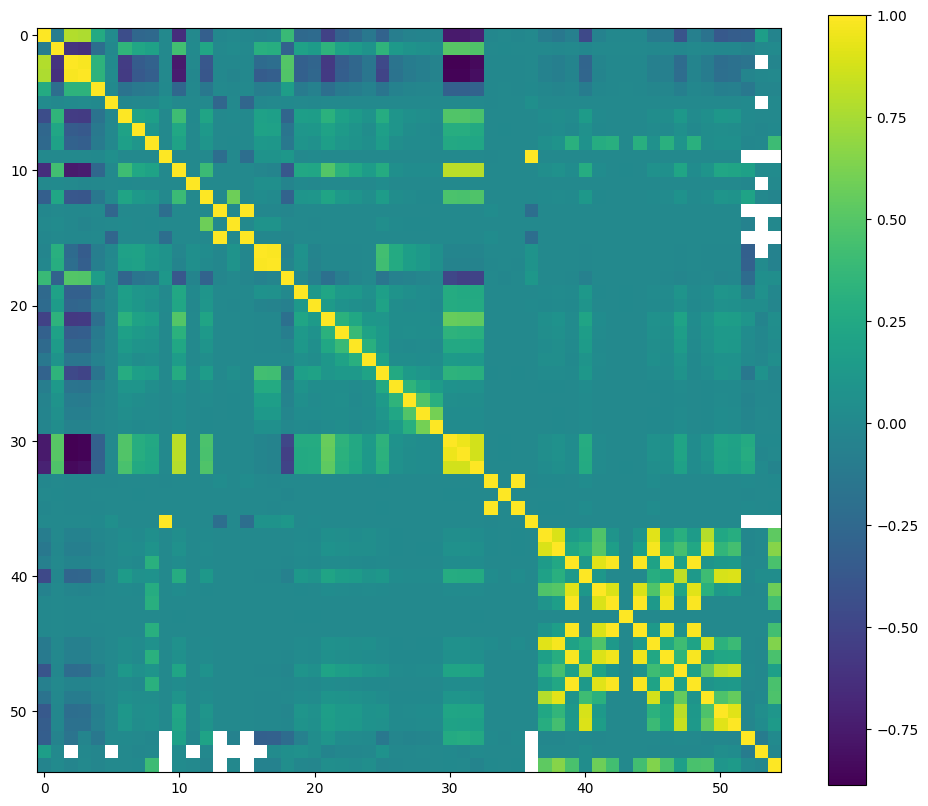

In [ ]:
import matplotlib.pyplot as plt

corr = feature_table.select_dtypes("number").corr()

plt.figure(figsize=(12,10))
plt.imshow(corr)
plt.colorbar()
plt.show()

In [27]:
from src.feature import build_feature_table

feature_table = build_feature_table(
    sanpham=sanpham,
    tonkho=tonkho,
    nhapkho=nhapkho,
    xuatkho=xuatkho,
    cham=cham,
)

display(feature_table.head())
display(feature_table.describe(include="all"))

,san_pham_id,nganh_hang_id,tong_nhap,ton_kho,tong_xuat,tan_suat_xuat,abc_class,ti_le_cham_hang,shelf_life_days,remaining_shelf_life_days,inventory_age_days
0,12504073.0,12501018.0,0.0,0.0,0.0,0.0,C,0.000000,NaN,NaN,NaN
1,20003159.0,12501018.0,40.0,0.0,56.0,7.0,C,0.000000,NaN,NaN,376.000000
2,12504099.0,12501018.0,200.0,0.0,256.0,21.0,C,0.047619,NaN,NaN,351.333333
3,12504065.0,12501018.0,1308.0,48.0,1314.0,94.0,C,0.063830,1050.25,1026.055556,234.100000
4,12504075.0,12501018.0,924.0,210.0,372.0,34.0,C,0.205882,1049.00,1009.750000,347.200000


,san_pham_id,nganh_hang_id,tong_nhap,ton_kho,tong_xuat,tan_suat_xuat,abc_class,ti_le_cham_hang,shelf_life_days,remaining_shelf_life_days,inventory_age_days
count,3.483160e+05,3.483160e+05,3.483160e+05,3.483160e+05,3.483160e+05,348316.000000,348316,348316.000000,6625.000000,6639.000000,8339.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,C,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,346145,NaN,NaN,NaN,NaN
mean,5.297108e+07,5.050358e+07,2.622718e+02,5.546387e+01,1.494247e+02,3.010413,NaN,0.003620,758.335096,703.696209,166.571911
std,6.536041e+06,1.187805e+07,1.709971e+04,9.994228e+03,7.263686e+03,149.283553,NaN,0.198063,502.452978,479.902221,91.926755
min,2.171910e+05,0.000000e+00,0.000000e+00,-1.248000e+03,0.000000e+00,0.000000,NaN,0.000000,9.555556,-209.000000,2.000000
25%,5.432981e+07,5.421719e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,NaN,0.000000,365.000000,324.548246,113.875000
50%,5.450450e+07,5.421719e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,NaN,0.000000,730.000000,684.500000,181.888889
75%,5.467991e+07,5.421719e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,NaN,0.000000,1095.750000,1013.591667,218.000000


In [28]:
from pathlib import Path

output_dir = Path("../data/process")
output_dir.mkdir(parents=True, exist_ok=True)

feature_table.to_csv(
    output_dir / "feature_table.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu:", output_dir / "feature_table.csv")

Đã lưu: ..\data\process\feature_table.csv
